# IND320 Project Work, Part 1

**Course:** IND320 Data to Decision  
**Student:** Sara Christine Gjerløw  

**GitHub repository:** https://github.com/SaraGjerlow/ind320-SaraGjerlow  
**Streamlit app:** https://ind320-saragjerlow.streamlit.app

This notebook reads and explores weekly reservoir statistics for Norwegian
hydropower, and prepares the data series that the Streamlit app displays.

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Read the file using Pandas

The file `reservoirs.csv` comes from the course repository D2Dbook. It contains
NVE's weekly reservoir statistics. Each row is one measurement of how much
energy is stored in Norwegian hydropower reservoirs in a given week.

In [2]:
# Read the raw CSV file
df = pd.read_csv("../data/reservoirs.csv")

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (14877, 11)


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


The file has 14877 rows and 11 columns. 

Most of the columns look self-explanatory, but `omrType` and `omrnr` do not,
and the first rows all have the same `omrType`. Since these two columns decide
which rows belong together, I check them before doing anything else.

In [3]:
# Check how many areas the file contains before choosing what to keep
print(df.groupby(["omrType", "omrnr"]).size())

omrType  omrnr
EL       1        1653
         2        1653
         3        1653
         4        1653
         5        1653
NO       0        1653
VASS     1        1653
         2        1653
         3        1653
dtype: int64


The output shows nine groups, each with exactly 1653 rows. So it looks like the file is not
one time series but nine stacked on top of each other, one per area.

`omrType` has three values. NO has a single area numbered 0, EL has five areas
and VASS has three. Since NO covers the whole country in one series, I keep
those rows, which gives one value per week for each column.

One more thing I need to do before the data can be plotted is to sort the rows by date. I can see that the first rows are from both 1995, 2020 and 2011, very random, so the file has to be sorted.

In [4]:
# Keep only the national total (NO)
national = df[df["omrType"] == "NO"].copy()

# Turn the date column into real dates, then sort the rows by date
national["dato_Id"] = pd.to_datetime(national["dato_Id"])
national = national.sort_values("dato_Id")

print("Rows and columns:", national.shape)
print("First date:", national["dato_Id"].min())
print("Last date:", national["dato_Id"].max())
national.head()

Rows and columns: (1653, 11)
First date: 1995-01-08 00:00:00
Last date: 2026-09-06 00:00:00


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
8501,1995-01-08,NO,0,1995,1,0.608274,87.43758,53.185986,0001-01-01T00:00:00,0.752703,-0.144430
8768,1995-01-15,NO,0,1995,2,0.582372,87.43758,50.921207,0001-01-01T00:00:00,0.608274,-0.025902
9035,1995-01-22,NO,0,1995,3,0.562412,87.43758,49.175980,0001-01-01T00:00:00,0.582390,-0.019977
8870,1995-01-29,NO,0,1995,4,0.534508,87.43758,46.736122,0001-01-01T00:00:00,0.562412,-0.027904
8316,1995-02-05,NO,0,1995,5,0.506486,87.43758,44.285900,0001-01-01T00:00:00,0.534489,-0.028003


The 14877 rows are now 1653, one per week, and the first rows are in date order. The data runs from january 1995 to september 2026.

## 3. Rename headers to English

The source headers are Norwegian, so they must be translated for everyone in this course to understand:)

I also think some of the columns can be dropped, because they are not useful:
- `omrType` and `omrnr` are the same in every row after filtering
- `iso_aar` and `iso_uke` repeat information that is already in the `dato_Id` column
- `neste_Publiseringsdato` is a publication timestamp rather than a measurement

In [5]:
# Keep the date and the five measurement columns
data = national[[
    "dato_Id",
    "fyllingsgrad",
    "kapasitet_TWh",
    "fylling_TWh",
    "fyllingsgrad_forrige_uke",
    "endring_fyllingsgrad",
]]

# Translate the Norwegian headers to English
data = data.rename(columns={
    "dato_Id": "Date",
    "fyllingsgrad": "Fill level (fraction)",
    "kapasitet_TWh": "Capacity (TWh)",
    "fylling_TWh": "Stored energy (TWh)",
    "fyllingsgrad_forrige_uke": "Fill level previous week (fraction)",
    "endring_fyllingsgrad": "Change in fill level (fraction)",
})

# Use the date as the row index, so it becomes the x-axis in the plots
data = data.set_index("Date")

data.head()

,Fill level (fraction),Capacity (TWh),Stored energy (TWh),Fill level previous week (fraction),Change in fill level (fraction)
Date,,,,,
1995-01-08,0.608274,87.43758,53.185986,0.752703,-0.144430
1995-01-15,0.582372,87.43758,50.921207,0.608274,-0.025902
1995-01-22,0.562412,87.43758,49.175980,0.582390,-0.019977
1995-01-29,0.534508,87.43758,46.736122,0.562412,-0.027904
1995-02-05,0.506486,87.43758,44.285900,0.534489,-0.028003


Now the data has english headers. The unit is included in the new names, because `fyllingsgrad` is a fraction between 0 and 1 and not a percentage, which is easy to misread.

## 4. Print the contents

`describe()` gives the range of each column, which is useful here because the
columns are measured in different units.

In [6]:
data.describe()

,Fill level (fraction),Capacity (TWh),Stored energy (TWh),Fill level previous week (fraction),Change in fill level (fraction)
count,1653.000000,1653.00000,1653.000000,1653.000000,1653.000000
mean,0.622086,87.43758,54.393716,0.622156,-0.000070
std,0.195967,0.00000,17.134922,0.195992,0.027704
min,0.180250,87.43758,15.760602,0.180260,-0.144430
25%,0.460607,87.43758,40.274364,0.460607,-0.022063
50%,0.645902,87.43758,56.476093,0.647445,-0.005650
75%,0.789274,87.43758,69.012170,0.789271,0.016337
max,0.966916,87.43758,84.544820,0.966892,0.125069


The five columns have very different ranges. Fill level runs from about 0.19 to
0.96, stored energy from about 16 to 85 TWh, and the weekly change is a small
number around zero. Capacity has a standard deviation of 0, which means it is
the same value in every row.

## 5. Plot each column separately

One figure per column, so that each variable is shown on its own scale.

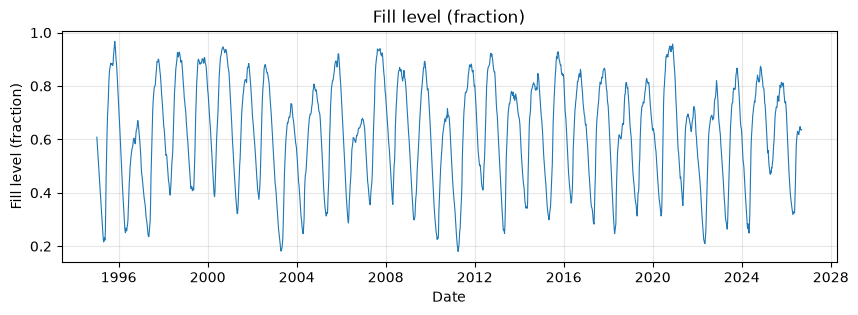

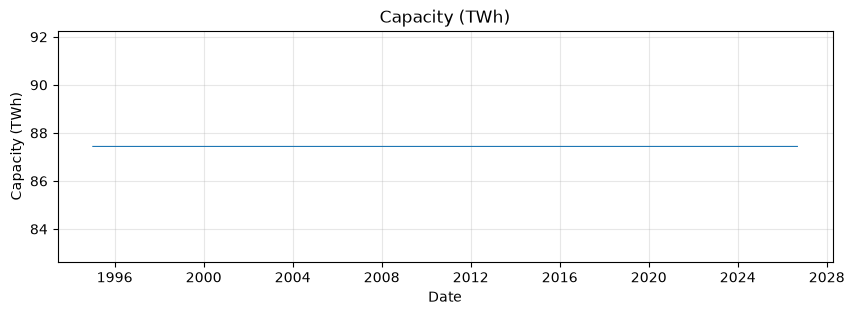

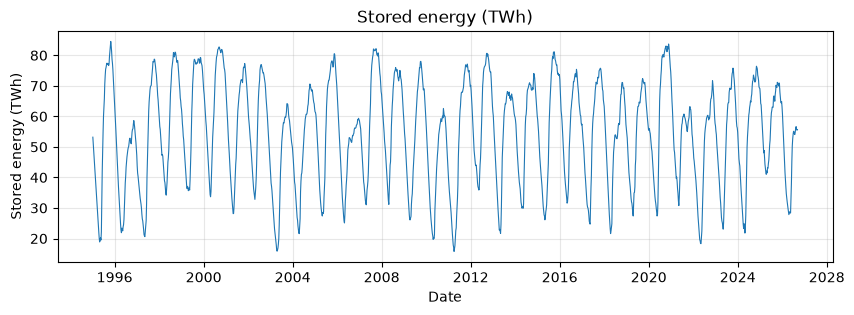

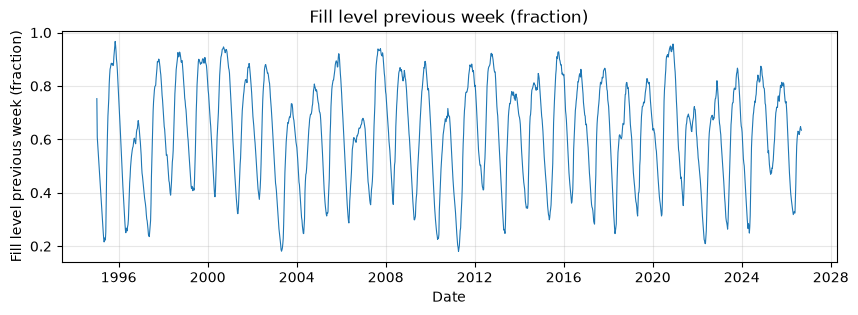

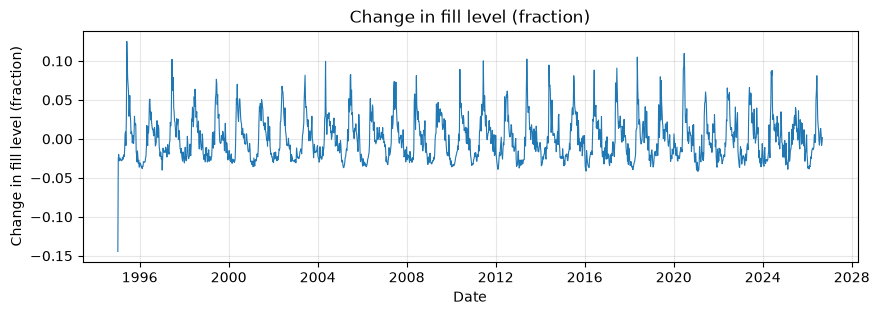

In [7]:
# Loop through the columns and draw one figure for each
for column in data.columns:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(data.index, data[column], linewidth=0.8)
    ax.set_title(column)
    ax.set_xlabel("Date")
    ax.set_ylabel(column)
    ax.grid(alpha=0.3)
    plt.show()

Three things stand out.

Fill level swings up and down in a regular pattern that repeats about once per
year. The x-axis covers 31 years, so I cannot read off which months the peaks
and troughs fall in, but a yearly cycle in Norwegian reservoirs most likely
follows the seasons.

As `describe()` already showed, capacity has a standard deviation of 0, and the
plot confirms it, because its a flat line across the whole period.

Fill level and fill level previous week look identical, because one is the other
shifted by a single week.

## 6. Plot all columns together

The columns use different units. Two are energy in TWh with values up to about
87, two are fractions between 0 and 1, and one is a weekly change around zero.
Drawn on the same axis without any adjustment, the three small columns would be
flat lines along the bottom.

To make the plot readable, each column is rescaled to run from 0 to 1 using
min-max normalisation. The cost is that the real values are gone from the plot:
you can see whether two columns rise and fall together, but not how large they
are.

Capacity is the same value in every row, so it has no range to rescale by and
would give a division by zero. It is left out of this plot.

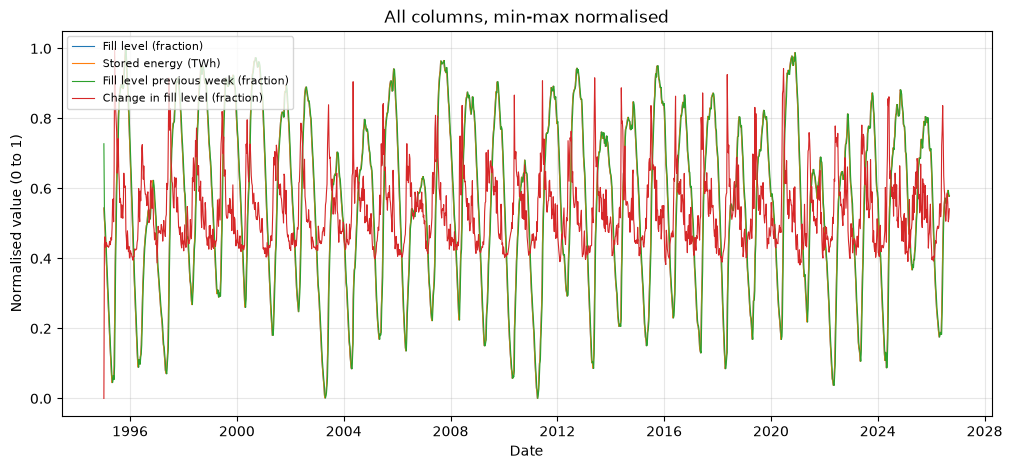

In [8]:
# The four columns to plot, capacity excluded
columns_to_plot = [
    "Fill level (fraction)",
    "Stored energy (TWh)",
    "Fill level previous week (fraction)",
    "Change in fill level (fraction)",
]

fig, ax = plt.subplots(figsize=(12, 5))

for column in columns_to_plot:
    values = data[column]
    # Min-max normalisation: rescale the column so it runs from 0 to 1
    normalised = (values - values.min()) / (values.max() - values.min())
    ax.plot(data.index, normalised, linewidth=0.8, label=column)

ax.set_title("All columns, min-max normalised")
ax.set_xlabel("Date")
ax.set_ylabel("Normalised value (0 to 1)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="upper left")
plt.show()

Only two curves are visible, even though four are drawn. Fill level (blue) and fill level previous week (green) are the same series shifted by one week, so they overlap. Stored energy (orange) is fill level multiplied by capacity, and since capacity is constant, rescaling makes it identical to fill level as well. Green is drawn last and covers the other two.

The red curve, the weekly change, is the only one that looks different. It is much noisier, since it measures the difference between two weeks rather than a level.

## Log

Most of my time on this part went to getting the environment right, not to
writing code. I have a MacBook with an Intel processor, and Homebrew stopped
building packages for Intel in September 2026, so the installation I started
with failed. I installed Python 3.13 from python.org instead, which worked
without any problems. I chose 3.13 because Streamlit Community Cloud only
supports Python versions that still receive security updates, and I wanted the
same version locally and in the cloud. I deployed the app before I noticed that
the Python version has to be set under Advanced settings, and since that setting
cannot be changed afterwards I had to delete the app and deploy it again.

The worst problem was harder to spot. My project folder was in Documents, which
syncs to iCloud, and iCloud tried to upload every file inside the virtual
environment. A cell that reads a CSV file took more than eleven minutes to run,
and the kernel kept timing out. Moving the project out of iCloud and rebuilding
the virtual environment solved it completely. I now keep code outside Documents.

One thing that worked well was deploying an empty app skeleton to Streamlit
Cloud before writing any real code. When the deployment failed, I knew the
problem was the environment and not my own logic. I also ran into a rejected
push because the remote branch was ahead of my local one, which I solved with
git pull --rebase.

In the notebook, the main surprise was the data itself. The file is in long
format with nine different areas stacked on top of each other, so it is not one
time series but nine. I kept the national total so that each column becomes a
single series. The columns also use different units, and deciding how to plot
them together took more thought than I expected. I ended up rescaling each
column to the same range and explaining what that costs.

I had never used Streamlit before, but I have built an iOS app in Xcode. The
biggest adjustment was that a Streamlit script reruns from top to bottom every
time the user interacts with a widget, instead of a view reacting to an event.
Caching with st.cache_data makes more sense once that is clear. Getting
LineChartColumn to work also meant building the table the other way round, with
one row per variable rather than one row per week.

If I were starting again I would check the file layout and my environment before
writing anything.

## AI declaration

I used **Claude** throughout the work, mainly for environment setup and
debugging, and for suggestions on code structure and Streamlit syntax. I used
**Gemini** to understand how Streamlit differs from frameworks I have used before.
All code was reviewed and adapted by me, and factual claims about the dataset
were verified against NVE's documentation before being included.